In [ ]:
import numpy as np
from scipy.io import loadmat
import nibabel as nb
import os
import sys
import matplotlib.pyplot as plt

core_functions_path = os.path.abspath('../core_functions')
sys.path.append(core_functions_path)


from compute_eigenvectors_sliding_cov import compute_eigs_cov
from dysco_distance import dysco_distance
from dysco_mode_alignment import dysco_mode_alignment
from dysco_norm import dysco_norm
from fMRI_Processing.surf_cifti_data import surf_data_from_cifti



# Simple DySCO Tutorial 

### If you want to learn how to use dysco this is the right place! This script teaches you how to run the core functions to build your dysco analysis pipeline

## Step 1: Load the timeseries. 
### This should be a matrix, each row is a timepoint, each column is a signal/brain area/feature. So it's TxN. 

### This might be the most ~annoying~ crucial part, the data preprocessing/format. Here we will use .nii format and use nibabel to load. But there are many other ways to do this. 

#### N.B. IF you have a suitable .nii file input the full path into the 'file_path', ALTERNATIVELY, we have done this step on an existing .nii file from the HCP project and saved it as an .npy file. If you wish to use this, skip the next cell and load the .npy file

In [35]:
# SKIP THIS CELL (Unless you have a .nii file)
'''
try:
    file_path = '*.nii'

    # Load NIfTI file
    cifti = nb.load(file_path)
    cifti_data = cifti.get_fdata(dtype=np.float32)
    cifti_hdr = cifti.header
    nifti_hdr = cifti.nifti_header

    axes = [cifti_hdr.get_axis(i) for i in range(cifti.ndim)]

    # Only using half the brain here 
    left_brain = surf_data_from_cifti(cifti_data, axes[1], 'CIFTI_STRUCTURE_CORTEX_LEFT')
    # right_brain = surf_data_from_cifti(cifti_data, axes[1], 'CIFTI_STRUCTURE_CORTEX_RIGHT')

    brain_load = left_brain

    # Can filter here (based on tissue boundaries etc)
    brain_load = brain_load.T
    zero_columns = np.all(brain_load == 0, axis=0)
    filtered_array = brain_load[:, ~zero_columns]
    brain = filtered_array
except Exception as e:
    print("You need an appropriate .nii file - See Above")
    pass
'''

'\ntry:\n    file_path = \'*.nii\'\n\n    # Load NIfTI file\n    cifti = nb.load(file_path)\n    cifti_data = cifti.get_fdata(dtype=np.float32)\n    cifti_hdr = cifti.header\n    nifti_hdr = cifti.nifti_header\n\n    axes = [cifti_hdr.get_axis(i) for i in range(cifti.ndim)]\n\n    # Only using half the brain here \n    left_brain = surf_data_from_cifti(cifti_data, axes[1], \'CIFTI_STRUCTURE_CORTEX_LEFT\')\n    # right_brain = surf_data_from_cifti(cifti_data, axes[1], \'CIFTI_STRUCTURE_CORTEX_RIGHT\')\n\n    brain_load = left_brain\n\n    # Can filter here (based on tissue boundaries etc)\n    brain_load = brain_load.T\n    zero_columns = np.all(brain_load == 0, axis=0)\n    filtered_array = brain_load[:, ~zero_columns]\n    brain = filtered_array\nexcept Exception as e:\n    print("You need an appropriate .nii file - See Above")\n    pass\n'

In [4]:
# RUN this cell to load the saved .npy file
#brain = np.load('Test_Brain/Test_Brain_1.npy')

In [3]:
'''Get the file path '''

file_path = "C:/Users/naima/DySCo-main/DySCo-main/fake_fmri_data/fake_step_bold.nii"

nifti = nb.load(file_path)
fmri_data= nifti.get_fdata()
brain = fmri_data

# Check what shape your brain data actually has
print("Your brain data shape:", brain.shape)

# If it's 4D (x, y, z, time), convert it to 2D
if len(brain.shape) == 4:
    # Reshape to (time, voxels)
    brain_2d = brain.reshape(-1, brain.shape[-1]).T
    print("Converted to 2D shape:", brain_2d.shape)
   
else:
    print("Your brain data already has shape:", brain.shape)


Your brain data shape: (64, 64, 20, 120)
Converted to 2D shape: (120, 81920)


## Step 2: Run the recurrence matrix EVD

### After you have selected the type of matrix (see paper) and preprocessed the data, run the recurrence matrix EVD for the specified matrix. For example, here we are running it for a sliding window correlation matrix with a window of 21 (odd numbers for symmetry). Remember that the rank (=n of non-null eigenvalues) is lower than window size (see paper). In this case, we calculate the first 10 eigenvectors as an example.

In [4]:
half_window_size = 10
n_eigen = 10

brain_2d = np.nan_to_num(brain_2d)
brain_2d = brain_2d.astype(np.float64)
brain_2d = np.array(brain_2d) 
#brain_array = np.array(brain)
print(type(brain_2d))
#print(brain_array.shape)



#for some reason, i ahve to add tiny noise --
brain_2d_regularized = brain_2d + 1e-6 * np.random.randn(*brain_2d.shape)
eigenvectors, eigenvalues = compute_eigs_cov(brain_2d_regularized, n_eigen, half_window_size)

print(brain_2d.shape)




eigenvectors, eigenvalues = compute_eigs_cov(brain_2d_regularized, n_eigen, half_window_size)


<class 'numpy.ndarray'>


Calculating eigenvectors and eigenvalues:: 100%|██████████| 100/100 [00:07<00:00, 12.77it/s]


(120, 81920)


Calculating eigenvectors and eigenvalues:: 100%|██████████| 100/100 [00:07<00:00, 13.16it/s]


### Now you have eigenvectors and eigenvalues. eigenvalues is a 2D matrix, where each column corresponds to our 10 eigenvalues at each time point. eigenvectors is 3D, because it is a matrix of eigenvectors for each time point. Every column of the matrix is an eigenvector, and indeed every matrix has 10 columns.

## Step 3: Compute DySCo measures:

### Now that we have this EVD representation of our sliding-window correlation matrix, we can compute the DySCo measures.

#### These are: 
1. NORM 
2. DISTANCE 
3. Reconfiguration Speed 
4. Entropy


## Norm

### This is the time-varying norm, computed from eigenvalues (see paper), so at each time point you have the norm of the matrix. Let us compute the norm 2, but there are different norms available (see paper).

In [5]:


norm2 = dysco_norm(eigenvalues, 2)

In [6]:
# a1. From norm we can compute a derived measure, which is spectral
# metastability - see paper.
metastability = np.std(norm2)

## Distance

### We can compute the distance between dynamic matrices at 2 different time points. For example, let us use the distance 2 to compute the Functional Connectivity Dynamics (FCD) matrix.

In [18]:
T = eigenvectors.shape[0]
fcd = np.zeros((T, T))

for i in range(T):
    for j in range(i + 1, T):
        fcd[i, j] = dysco_distance(eigenvectors[i, :, :], eigenvectors[j, :, :], 2)
        fcd[j, i] = fcd[i, j]



## Reconfiguration speed

### is just the distance between the matrix at time t and the matrix at time t-lag, so if we already have the FCD matrix, the reconfiguration speed will be just derived from that: (here we suppose lag = 5)

In [19]:
lag = 20
speed = np.zeros(T - lag)
for i in range(T - lag):
    speed[i] = fcd[i, i + lag]
    

## Entropy

### For Von Neumann Entropy, you just need the eigenvalues (like for the norm).

In [20]:
                      
entropy = eigenvalues / np.tile(np.sum(eigenvalues, axis=0), (n_eigen, 1))
entropy = -np.sum(np.log(entropy) * entropy, axis=0)


In [21]:
eigenvalues.shape


(10, 100)

In [22]:
import os
import numpy as np

# Create folder if it doesn't exist
folder_path = "test_data_dysco_measures"
os.makedirs(folder_path, exist_ok=True)

# Create a dictionary with all your DySCo measures
dysco_measures = {
    'norm2': norm2,
    'metastability': metastability,
    'speed': speed,
    'entropy': entropy,
    'fcd': fcd,
    'eigenvalues': eigenvalues,
    'eigenvectors': eigenvectors
}

# Save to .npy file
output_file = os.path.join(folder_path, "fake_step_data.npy")
np.save(output_file, dysco_measures)

print(f"DySCo measures saved to: {output_file}")
print("Measures included:")
for key, value in dysco_measures.items():
    print(f"  {key}: {value.shape if hasattr(value, 'shape') else type(value)}")

DySCo measures saved to: test_data_dysco_measures\fake_step_data.npy
Measures included:
  norm2: (100,)
  metastability: ()
  speed: (80,)
  entropy: (100,)
  fcd: (100, 100)
  eigenvalues: (10, 100)
  eigenvectors: (100, 81920, 10)


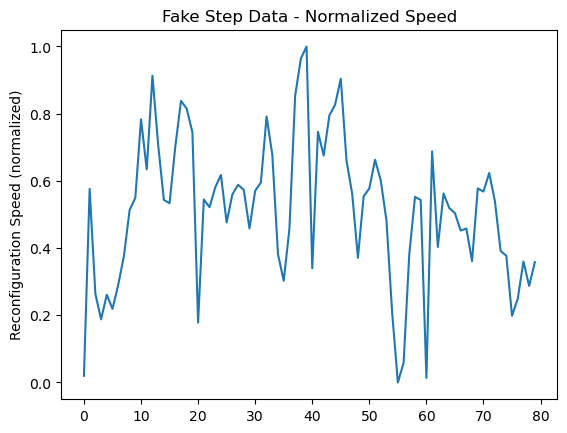

In [25]:
import numpy as np
import matplotlib.pyplot as plt

path = "C:/Users/naima/DySCo-main/DySCo-main/Python/Pipelines/test_data_dysco_measures/fake_step_data.npy"
array = np.load(path, allow_pickle=True).item()
speed = array["speed"]

# Min-max normalization (BEST for speed)
speed_norm = (speed - np.min(speed)) / (np.max(speed) - np.min(speed))

plt.plot(speed_norm)
plt.ylabel('Reconfiguration Speed (normalized)')
plt.title('Fake Step Data - Normalized Speed')
plt.show()


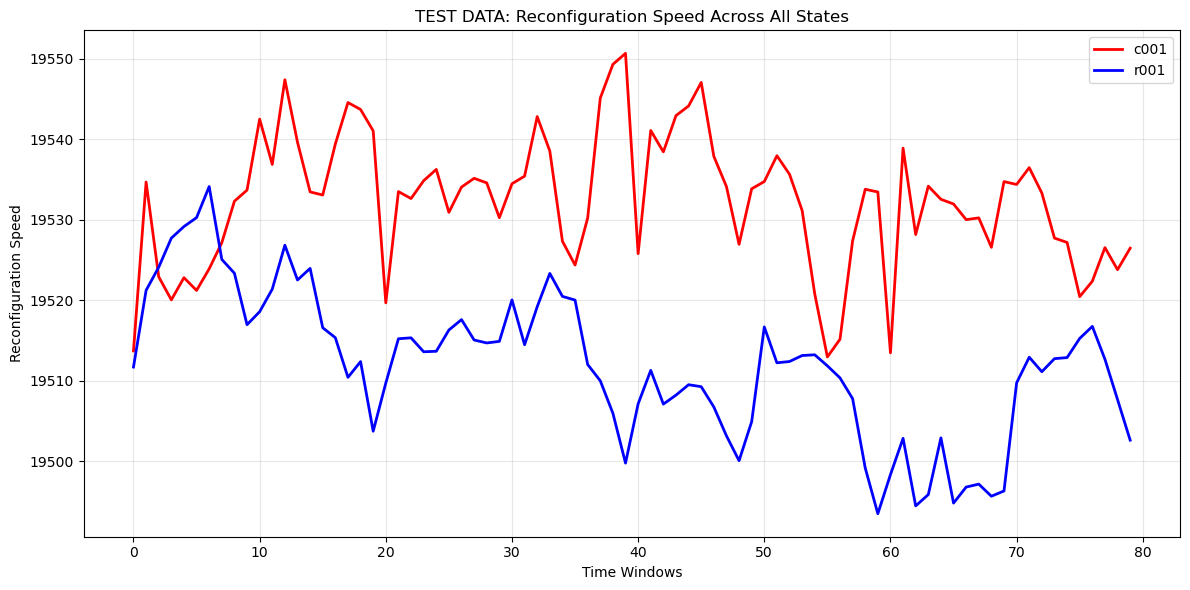

In [49]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ONE base path
#base_path = "C:/Users/naima/PycharmProjects/DySCo/Python/Pipelines/P002_dysco_measures"

base_path = "C:/Users/naima/DySCo-main/DySCo-main/Python/Pipelines/test_data_dysco_measures"

# P002
conditions = ['c001', 'r001']
colors = ['red','blue']
labels = ['c001', 'r001']

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

for condition, color, label in zip(conditions, colors, labels):
    # P002
    filename = f"{condition}_dysco.npy"
    full_path = os.path.join(base_path, filename)
    
    # Load data
    data = np.load(full_path, allow_pickle=True).item()
    speed = data["speed"]
    
    # Plot
    ax.plot(speed, color=color, label=label, linewidth=2)

# Format plot
ax.set_xlabel('Time Windows')
ax.set_ylabel('Reconfiguration Speed')
ax.set_title('TEST DATA: Reconfiguration Speed Across All States')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

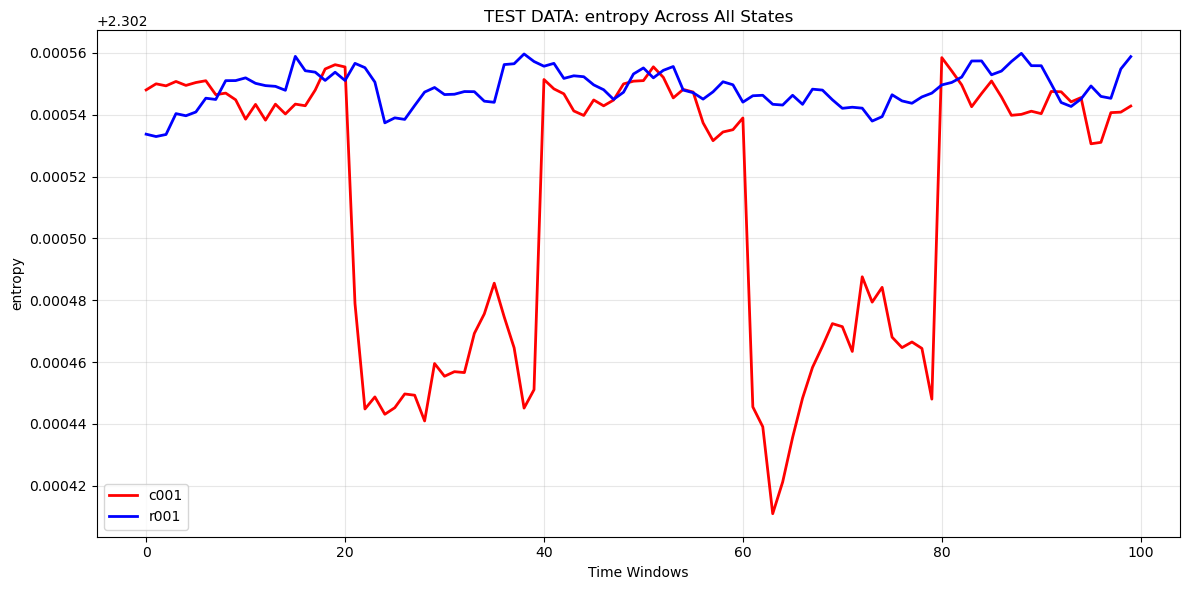

In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ONE base path
#base_path = "C:/Users/naima/PycharmProjects/DySCo/Python/Pipelines/P002_dysco_measures"

base_path = "C:/Users/naima/DySCo-main/DySCo-main/Python/Pipelines/test_data_dysco_measures"

# P002
conditions = ['c001', 'r001']
colors = ['red','blue']
labels = ['c001', 'r001']

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

for condition, color, label in zip(conditions, colors, labels):
    # P002
    filename = f"{condition}_dysco.npy"
    full_path = os.path.join(base_path, filename)
    
    # Load data
    data = np.load(full_path, allow_pickle=True).item()
    entropy = data["entropy"]
    
    # Plot
    ax.plot(entropy, color=color, label=label, linewidth=2)

# Format plot
ax.set_xlabel('Time Windows')
ax.set_ylabel('entropy')
ax.set_title('TEST DATA: entropy Across All States')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

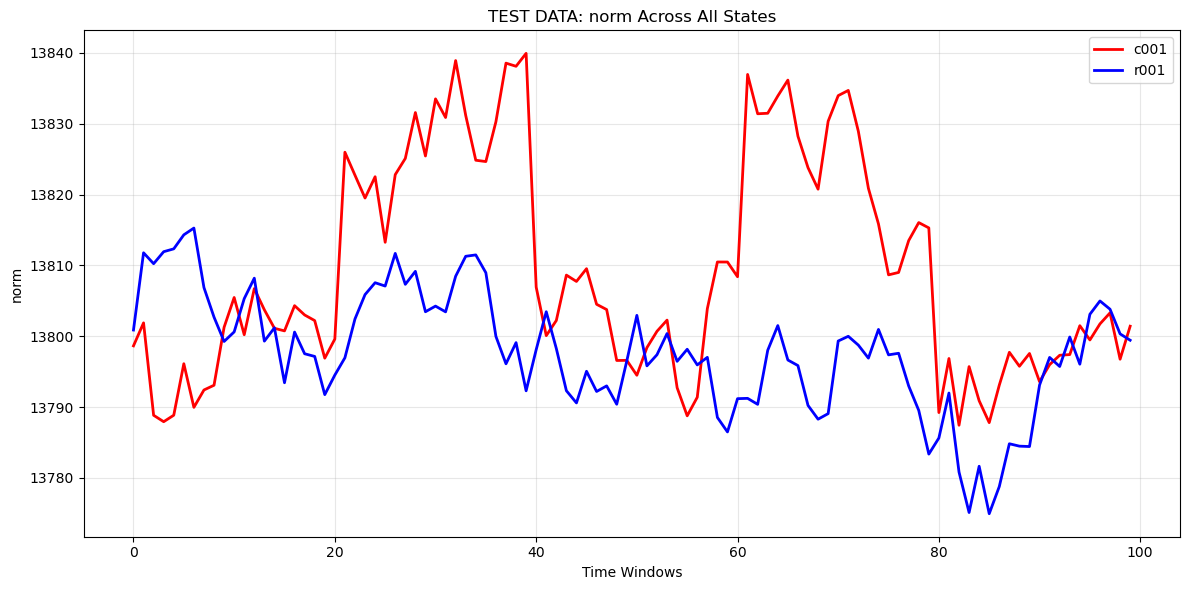

In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ONE base path
#base_path = "C:/Users/naima/PycharmProjects/DySCo/Python/Pipelines/P002_dysco_measures"
base_path = "C:/Users/naima/DySCo-main/DySCo-main/Python/Pipelines/test_data_dysco_measures"

# P002
conditions = ['c001', 'r001']
colors = ['red','blue']
labels = ['c001', 'r001']

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

for condition, color, label in zip(conditions, colors, labels):
    # P002
    filename = f"{condition}_dysco.npy"
    full_path = os.path.join(base_path, filename)
    
    # Load data
    data = np.load(full_path, allow_pickle=True).item()
    norm = data["norm2"]  
    # Plot
    ax.plot(norm, color=color, label=label, linewidth=2)  # Changed from entropy to nrom

# Format plot
ax.set_xlabel('Time Windows')
ax.set_ylabel('norm')  # Changed from entropy to norm
ax.set_title('TEST DATA: norm Across All States')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# -------- FILE PATH --------
nifti_file = "C:/Users/naima/DySCo-main/DySCo-main/DELFT_NEW/P001/p001_allruns_4d.gz"

# -------- LOAD DATA --------
img = nib.load(nifti_file)
data = img.get_fdata()

print("Data shape:", data.shape)  
# expected: (x, y, z, time)

# -------- EXTRACT MEAN BOLD --------
# average across all voxels for each time point
bold_timecourse = np.mean(data, axis=(0,1,2))

# -------- TIME AXIS --------
T = bold_timecourse.shape[0]
time = np.arange(T)

# -------- PLOT --------
plt.figure(figsize=(12,5))
plt.plot(time, bold_timecourse)

plt.xlabel("Time (TR)")
plt.ylabel("Mean BOLD Signal")
plt.title("Raw BOLD Timecourse")
plt.grid(True)

plt.show()

ImageFileError: Cannot work out file type of "C:/Users/naima/DySCo-main/DySCo-main/DELFT_NEW/P001/p001_allruns_4d.gz"